# Two-Sample t-Test

The **two-sample t-test** compares the means of two independent groups. Welch's version (unequal variances) is preferred over the pooled version because it is robust to heteroscedasticity with minimal loss of power.

| Property | Value |
|---|---|
| **H₀** | μ₁ = μ₂ (equivalently, μ₁−μ₂ = 0) |
| **H₁** | μ₁ ≠ μ₂ |
| **Test statistic** | t = (x̄₁−x̄₂) / √(s₁²/n₁ + s₂²/n₂) |
| **df (Welch)** | Satterthwaite approximation |
| **Assumptions** | Independence within and between groups; approximate normality |
| **Effect size** | Cohen's d = (x̄₁−x̄₂) / s_pooled |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

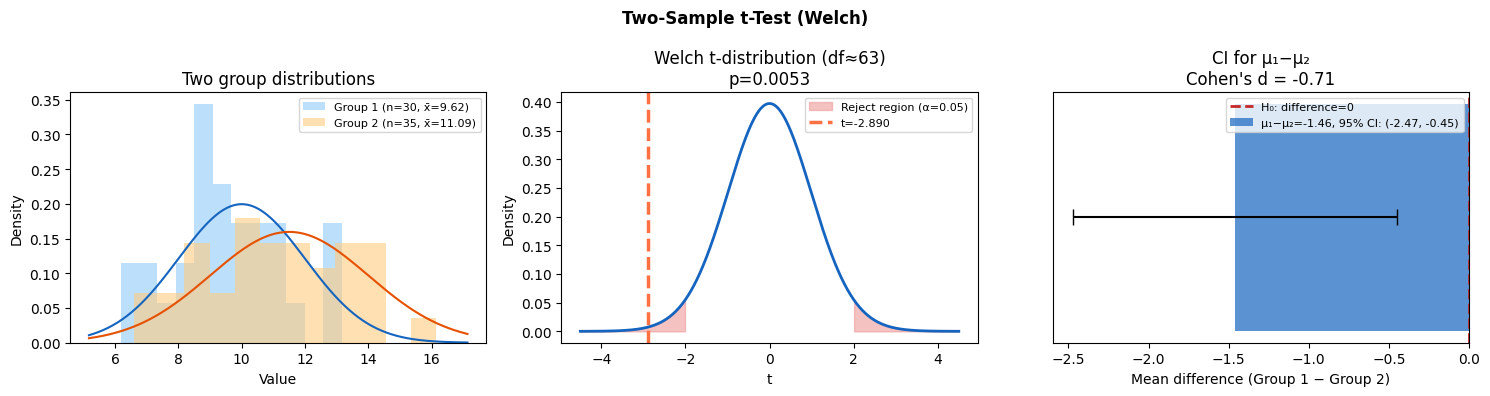

Welch t-test: t=-2.8903, df≈62.7, p=0.0053
Cohen's d = -0.706 (medium)
95% CI for difference: (-2.4742, -0.4513)


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Two-Sample t-Test (Welch)', fontsize=12, fontweight='bold')

# Generate two groups
n1, n2 = 30, 35
mu1, mu2 = 10.0, 11.5
s1, s2 = 2.0, 2.5
g1 = np.random.normal(mu1, s1, n1)
g2 = np.random.normal(mu2, s2, n2)

t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_welch)

# Panel 1: overlapping distributions
x = np.linspace(min(g1.min(), g2.min())-1, max(g1.max(), g2.max())+1, 400)
axes[0].hist(g1, bins=12, density=True, color='#90CAF9', alpha=0.6, label=f'Group 1 (n={n1}, x̄={g1.mean():.2f})')
axes[0].hist(g2, bins=12, density=True, color='#FFCC80', alpha=0.6, label=f'Group 2 (n={n2}, x̄={g2.mean():.2f})')
axes[0].plot(x, stats.norm(mu1, s1).pdf(x), color='#1565C0', lw=1.5)
axes[0].plot(x, stats.norm(mu2, s2).pdf(x), color='#E65100', lw=1.5)
axes[0].set_title('Two group distributions')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Panel 2: t-distribution
df_r = round(df_welch)
t_range = np.linspace(-4.5, 4.5, 500)
t_pdf = stats.t.pdf(t_range, df_welch)
axes[1].plot(t_range, t_pdf, color='#1565C0', lw=2)
axes[1].fill_between(t_range, t_pdf, where=t_range >= t_crit, color='#EF9A9A', alpha=0.6)
axes[1].fill_between(t_range, t_pdf, where=t_range <= -t_crit, color='#EF9A9A', alpha=0.6, label='Reject region (α=0.05)')
axes[1].axvline(t_stat, color='#FF7043', lw=2.5, ls='--', label=f't={t_stat:.3f}')
axes[1].set_title(f'Welch t-distribution (df≈{df_r})\np={p_val:.4f}')
axes[1].set_xlabel('t'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Panel 3: CI for difference + effect sizes
diff = g1.mean() - g2.mean()
se_diff = np.sqrt(g1.var(ddof=1)/n1 + g2.var(ddof=1)/n2)
ci_lo = diff - t_crit * se_diff
ci_hi = diff + t_crit * se_diff
s_pool = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
cohens_d = diff / s_pool

axes[2].barh([0], [diff], xerr=[[diff-ci_lo], [ci_hi-diff]],
             color='#1565C0', alpha=0.7, capsize=6, height=0.4,
             label=f'μ₁−μ₂={diff:.2f}, 95% CI: ({ci_lo:.2f}, {ci_hi:.2f})')
axes[2].axvline(0, color='#C62828', lw=2, ls='--', label='H₀: difference=0')
axes[2].set_title(f"CI for μ₁−μ₂\nCohen's d = {cohens_d:.2f}")
axes[2].set_xlabel('Mean difference (Group 1 − Group 2)')
axes[2].set_yticks([]); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Welch t-test: t={t_stat:.4f}, df≈{df_welch:.1f}, p={p_val:.4f}')
print(f"Cohen's d = {cohens_d:.3f} ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'})")
print(f'95% CI for difference: ({ci_lo:.4f}, {ci_hi:.4f})')

## Key Takeaways

| | |
|---|---|
| **Welch vs pooled** | Prefer Welch — it does not assume equal variances |
| **df (Welch)** | Satterthwaite approximation — typically non-integer |
| **Effect size** | Cohen's d: small=0.2, medium=0.5, large=0.8 |
| **CI for difference** | If 0 is outside the CI, reject H₀ |
| **Paired t-test** | For matched pairs, take differences and apply one-sample t-test |
| **Before t-test** | Check equal-variance assumption with Levene test if using pooled version |